In [1]:
%reload_ext autoreload
%autoreload 2


In [72]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.autoregressive import AutoregressiveTransformer
from probjax.nn.nets.transformer import Transformer
from probjax.nn.attention import flex_attention
from functools import partial
from probjax.stats import transformed, norm, independent
from probjax.nn.bijective import rational_quadratic_spline

from probjax.core import inverse

def affine_bijector(params, x):
    scale, shift = jnp.split(params, 2, axis=-1)
    scale = jnp.exp(scale*0.1)
    return x * scale + shift

def additive_bijector(params, x):
    print(params.shape, x.shape)
    return x + params

def spline_bijector(params, x):
    print(params.shape, x.shape)
    return jax.vmap(rational_quadratic_spline, in_axes=(0, 0))(params, x)

ar_transformer = AutoregressiveTransformer(
    in_out_dim=1,
    bijector_dim=150,
    bijector=spline_bijector,
    rngs=nnx.Rngs(1),
)

graphdef, params = nnx.split(ar_transformer)

In [73]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4,1)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4,1)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [74]:
p0 = independent(independent(norm(jnp.zeros((4,1)))))

In [75]:
def loss(params):
    model = nnx.merge(graphdef, params)
    p = transformed(p0, model)
    return -jnp.mean(p.logpdf(xs))

In [76]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [77]:
opt_state = optimizer.init(params)

In [86]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

9.173491
9.128516
9.142213
9.182061
9.1182995
9.165347
9.137667
9.12021
9.131252
9.135956
9.121898
9.141611
9.143393
9.127262
9.119681
9.123718
9.145262
9.137241
9.118217
9.122617
9.13315
9.155404
9.121486
9.1151705
9.13183
9.147493
9.147438
9.118379
9.114573
9.1328745
9.185198
9.125174
9.17244
9.157096
9.120396
9.143266
9.134963
9.118027
9.115994
9.121022
9.130845
9.128421
9.112012
9.120954
9.131209
9.134753
9.128541
9.118973
9.145692
9.170184
9.131785
9.156194
9.167024
9.141294
9.166432
9.132856
9.124454
9.124569
9.124651
9.124354
9.123797
9.122653
9.1316395
9.1374855
9.134617
9.120459
9.138567
9.16377
9.1350975
9.127438
9.167812
9.130394
9.16699
9.158372
9.119833
9.152088
9.147161
9.135276
9.198335
9.1460495
9.200567
9.135235
9.187485
9.13692
9.172648
9.149468
9.142078
9.163
9.133192
9.176508
9.130718
9.165262
9.126658
9.182173
9.127727
9.184599
9.121664
9.1835575
9.128386
9.168608
9.12403
9.14209
9.137795
9.127336
9.135074
9.123824
9.122191
9.137848
9.1416235
9.124602
9.147835
9.13

KeyboardInterrupt: 

In [82]:
p = transformed(p0, nnx.merge(graphdef, params))

In [83]:
samples = p.rvs(jax.random.PRNGKey(0), shape=(1000, ))

(4, 1)
(4, 150) (4, 1)


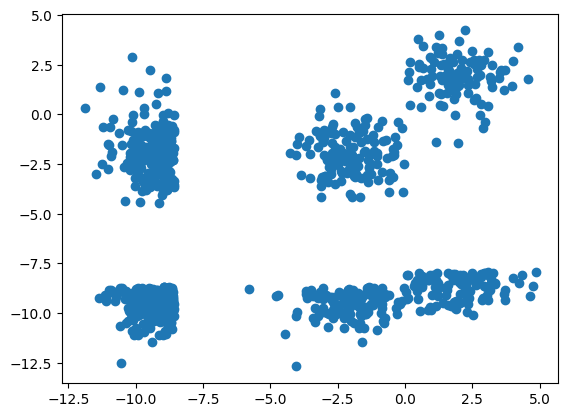

In [84]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])